# CISC 886 - Fine-Tuning Notebook  
## Cybersecurity URL Chatbot Assistant

This corrected version avoids the Unsloth Hugging Face statistics timeout by setting environment flags **before importing Unsloth**.

The notebook fine-tunes a lightweight instruction model to classify URLs as:
- safe / benign
- phishing / malicious

It also generates report-ready screenshots: dataset loading, EDA charts, training logs, loss curve, and base-vs-fine-tuned comparison.

## 1. Runtime Setup

Before running:

`Runtime > Change runtime type > GPU`

Recommended:
- GPU: T4
- Runtime: Python 3

In [1]:
!nvidia-smi

Wed Apr 29 15:09:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Install Libraries

This installs Unsloth and the training stack.

In [2]:
%%capture
!pip install -U "huggingface_hub[hf_transfer]" hf_transfer
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps trl peft accelerate bitsandbytes datasets pandas scikit-learn matplotlib

## 3. Set Environment Flags Before Importing Unsloth

This is important.  
The previous error happened during an Unsloth statistics check.  
These flags reduce that risk and make downloading more stable in Colab.

In [3]:
import os

os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"
os.environ["UNSLOTH_DISABLE_STATISTICS"] = "1"
os.environ["UNSLOTH_COMPILE_DISABLE"] = "1"

print("Environment flags set successfully.")

Environment flags set successfully.


## 4. Hugging Face Token

The token is requested at runtime.  
Do not write the token inside the notebook or commit it to GitHub.

In [4]:
from getpass import getpass
from huggingface_hub import login

hf_token = getpass("Paste your Hugging Face token: ").strip()

if not hf_token:
    raise ValueError("Token is empty. Paste a valid Hugging Face token.")

login(token=hf_token)
print("Hugging Face login completed.")

Paste your Hugging Face token: ··········
Hugging Face login completed.


## 5. Imports

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset, Dataset
from sklearn.model_selection import train_test_split

## 6. Load Dataset from Hugging Face

Dataset:

`semihGuner2002/PhishingURLsDataset`

Labels:
- `0` = benign / safe
- `1` = phishing / malicious

In [6]:
DATASET_NAME = "semihGuner2002/PhishingURLsDataset"

raw_ds = load_dataset(DATASET_NAME, token=hf_token)
raw_ds

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/27.8M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/4.91M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/642533 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/113389 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['url', 'label', '__index_level_0__'],
        num_rows: 642533
    })
    test: Dataset({
        features: ['url', 'label', '__index_level_0__'],
        num_rows: 113389
    })
})

## 7. Inspect Dataset

In [7]:
train_df_raw = raw_ds["train"].to_pandas()
test_df_raw = raw_ds["test"].to_pandas() if "test" in raw_ds else pd.DataFrame()

print("Train shape:", train_df_raw.shape)
print("Test shape:", test_df_raw.shape)
print("Columns:", train_df_raw.columns.tolist())

train_df_raw.head()

Train shape: (642533, 3)
Test shape: (113389, 3)
Columns: ['url', 'label', '__index_level_0__']


,url,label,__index_level_0__
0,aidatiye.live,1,471887
1,165.227.23.218,1,551846
2,yarditeracy.top,1,556212
3,dogsey.com/showthread.php?t=72452&page=10,0,175167
4,e-devletsistemgiris.com,1,664716


## 8. Clean and Deduplicate Data

This mirrors the Spark preprocessing logic:
- select `url` and `label`
- remove missing values
- lowercase URLs
- remove duplicated URLs
- calculate URL length

In [8]:
df = train_df_raw[["url", "label"]].copy()

df["url"] = df["url"].astype(str).str.lower().str.strip()
df["label"] = df["label"].astype(int)

df = df.dropna()
df = df.drop_duplicates(subset=["url"]).reset_index(drop=True)
df["url_length"] = df["url"].str.len()

print("Cleaned rows:", len(df))
print(df["label"].value_counts())

df.head()

Cleaned rows: 641842
label
1    347974
0    293868
Name: count, dtype: int64


,url,label,url_length
0,aidatiye.live,1,13
1,165.227.23.218,1,14
2,yarditeracy.top,1,15
3,dogsey.com/showthread.php?t=72452&page=10,0,41
4,e-devletsistemgiris.com,1,23


## 9. EDA Figure 1 - Label Distribution

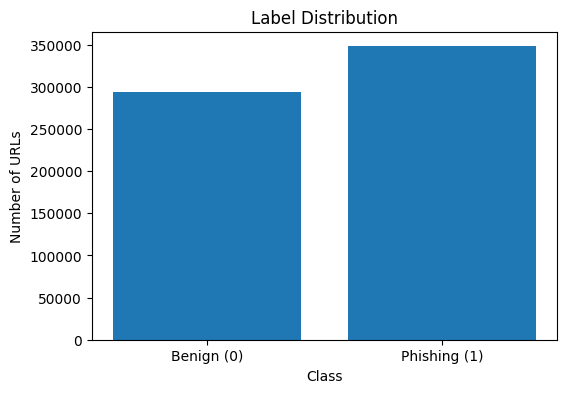

In [9]:
label_counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Benign (0)", "Phishing (1)"], [label_counts.get(0, 0), label_counts.get(1, 0)])
plt.title("Label Distribution")
plt.xlabel("Class")
plt.ylabel("Number of URLs")
plt.show()

## 10. EDA Figure 2 - URL Length Distribution

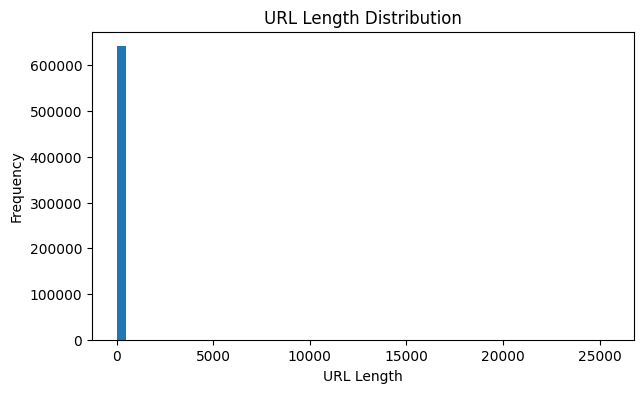

In [10]:
plt.figure(figsize=(7, 4))
plt.hist(df["url_length"], bins=50)
plt.title("URL Length Distribution")
plt.xlabel("URL Length")
plt.ylabel("Frequency")
plt.show()

## 11. Create Balanced Academic Training Subset

The full dataset is large.  
For a fast academic demonstration on Colab, this notebook uses a balanced subset.

Increase `SAMPLES_PER_CLASS` if you have more time.

In [11]:
SAMPLES_PER_CLASS = 3000
RANDOM_STATE = 42

safe_pool = df[df["label"] == 0]
phish_pool = df[df["label"] == 1]

target = min(SAMPLES_PER_CLASS, len(safe_pool), len(phish_pool))

balanced_df = pd.concat([
    safe_pool.sample(n=target, random_state=RANDOM_STATE),
    phish_pool.sample(n=target, random_state=RANDOM_STATE)
], ignore_index=True)

balanced_df = balanced_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("Balanced dataset shape:", balanced_df.shape)
print(balanced_df["label"].value_counts())

balanced_df.head()

Balanced dataset shape: (6000, 3)
label
0    3000
1    3000
Name: count, dtype: int64


,url,label,url_length
0,pixjm.com/?a=3895,0,17
1,qnbflnansbank-onlinehediyeler-com.tk,1,36
2,flickr.com/photos/xosara/6262552489/,0,36
3,scotteden.net/stories_fantasies.html,0,36
4,abysale.co.kr/technote/image/click/index.htm,1,44


## 12. Train / Validation / Test Split

Split:
- 70% training
- 15% validation
- 15% test

The split is stratified to preserve class balance.

In [12]:
train_df, temp_df = train_test_split(
    balanced_df,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=balanced_df["label"]
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_df["label"]
)

split_counts = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "count": [len(train_df), len(valid_df), len(test_df)]
})

print(split_counts)

        split  count
0       train   4200
1  validation    900
2        test    900


## 13. EDA Figure 3 - Split Counts

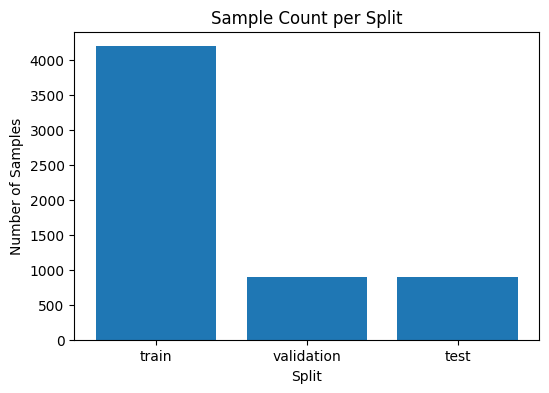

In [13]:
plt.figure(figsize=(6, 4))
plt.bar(split_counts["split"], split_counts["count"])
plt.title("Sample Count per Split")
plt.xlabel("Split")
plt.ylabel("Number of Samples")
plt.show()

## 14. Build Instruction-Tuning Prompts

The model is trained as a cybersecurity assistant, not only as a classifier.

Expected output format:
- Classification
- Risk level
- Reason

In [14]:
def make_reason(url, label):
    url = str(url)
    if int(label) == 1:
        if "login" in url or "verify" in url or "account" in url:
            return "The URL contains account or login-related wording, which is commonly used in phishing attempts."
        if any(ch.isdigit() for ch in url) and "." in url:
            return "The URL contains suspicious structure and numeric patterns often seen in malicious links."
        return "The URL pattern is associated with phishing or malicious behavior in the dataset."
    else:
        return "The URL appears consistent with benign web traffic patterns in the dataset."

def build_prompt(url):
    return f"""You are a cybersecurity URL analysis assistant.

Analyze the following URL and decide whether it is safe/benign or phishing/malicious.
Return the answer using this exact format:

Classification:
Risk level:
Reason:

URL: {url}
"""

def build_response(url, label):
    if int(label) == 1:
        return f"""Classification: phishing/malicious
Risk level: high
Reason: {make_reason(url, label)}"""
    else:
        return f"""Classification: safe/benign
Risk level: low
Reason: {make_reason(url, label)}"""

def to_instruction_df(input_df):
    rows = []
    for _, row in input_df.iterrows():
        rows.append({
            "prompt": build_prompt(row["url"]),
            "response": build_response(row["url"], row["label"]),
            "url": row["url"],
            "label": int(row["label"])
        })
    return pd.DataFrame(rows)

train_inst = to_instruction_df(train_df)
valid_inst = to_instruction_df(valid_df)
test_inst = to_instruction_df(test_df)

train_inst.head()

,prompt,response,url,label
0,You are a cybersecurity URL analysis assistant...,Classification: phishing/malicious\nRisk level...,27lelchgcvs2wpm7.wishsends.mobi,1
1,You are a cybersecurity URL analysis assistant...,Classification: safe/benign\nRisk level: low\n...,suttonunited.net/news.php,0
2,You are a cybersecurity URL analysis assistant...,Classification: safe/benign\nRisk level: low\n...,bradhusebasketball.blogspot.com/,0
3,You are a cybersecurity URL analysis assistant...,Classification: phishing/malicious\nRisk level...,xp17.com,1
4,You are a cybersecurity URL analysis assistant...,Classification: safe/benign\nRisk level: low\n...,wilmott.com/messageview.cfm?catid=34&threadid=...,0


## 15. Load Base Model

Primary model:

`unsloth/Llama-3.2-1B-Instruct-bnb-4bit`

Fallback model if the primary model fails:

`unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit`

Both are small instruction models suitable for Colab and PEFT/QLoRA.

In [15]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 512

candidate_models = [
    "unsloth/Llama-3.2-1B-Instruct-bnb-4bit",
    "unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit",
]

last_error = None

for model_name in candidate_models:
    try:
        print("Trying model:", model_name)
        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name=model_name,
            max_seq_length=max_seq_length,
            dtype=None,
            load_in_4bit=True,
            token=hf_token,
            disable_log_stats=True,
        )
        print("Base model loaded successfully:", model_name)
        break
    except Exception as e:
        print("Failed to load:", model_name)
        print("Error:", repr(e))
        last_error = e
else:
    raise RuntimeError(f"All candidate models failed. Last error: {last_error}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Trying model: unsloth/Llama-3.2-1B-Instruct-bnb-4bit
==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.03G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

Unsloth: Will load unsloth/Llama-3.2-1B-Instruct-bnb-4bit as a legacy tokenizer.


Base model loaded successfully: unsloth/Llama-3.2-1B-Instruct-bnb-4bit


## 16. Test Base Model Before Fine-Tuning

Use this output as the baseline comparison in the report.

In [29]:
FastLanguageModel.for_inference(model)

def generate_answer(prompt, max_new_tokens=160):
    inputs = tokenizer([prompt], return_tensors="pt").to("cuda")
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        temperature=0.2,
        top_p=0.9,
        do_sample=True,
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

example_url = "http://login-paypal-security-check.com/verify/account"
base_prompt = build_prompt(example_url)

base_response = generate_answer(base_prompt)
print(base_response)

Both `max_new_tokens` (=160) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


You are a cybersecurity URL analysis assistant.

Analyze the following URL and decide whether it is safe/benign or phishing/malicious.
Return the answer using this exact format:

Classification:
Risk level:
Reason:

URL: http://login-paypal-security-check.com/verify/account
Classification: phishing/malicious
Risk level: high
Reason: The URL pattern is associated with phishing or malicious behavior in the dataset.


## 17. Attach LoRA Adapters

LoRA is a PEFT method.  
It updates a small number of trainable parameters instead of fully fine-tuning the whole model.

In [17]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=RANDOM_STATE,
    use_rslora=False,
    loftq_config=None,
)

Unsloth 2026.4.8 patched 16 layers with 16 QKV layers, 16 O layers and 16 MLP layers.


## 18. Format Dataset for SFT Training

In [18]:
EOS_TOKEN = tokenizer.eos_token

def format_training_text(example):
    return {
        "text": example["prompt"] + "\n" + example["response"] + EOS_TOKEN
    }

train_dataset = Dataset.from_pandas(train_inst).map(format_training_text)
valid_dataset = Dataset.from_pandas(valid_inst).map(format_training_text)

print(train_dataset[0]["text"])

Map:   0%|          | 0/4200 [00:00<?, ? examples/s]

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

You are a cybersecurity URL analysis assistant.

Analyze the following URL and decide whether it is safe/benign or phishing/malicious.
Return the answer using this exact format:

Classification:
Risk level:
Reason:

URL: 27lelchgcvs2wpm7.wishsends.mobi

Classification: phishing/malicious
Risk level: high
Reason: The URL contains suspicious structure and numeric patterns often seen in malicious links.<|eot_id|>


## 19. Fine-Tune the Model

This is a short academic training run.  
For stronger results, increase `max_steps` or `SAMPLES_PER_CLASS`.

In [19]:
from trl import SFTTrainer
from transformers import TrainingArguments, DataCollatorForSeq2Seq
from unsloth import is_bfloat16_supported

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    dataset_text_field="text",
    max_seq_length=max_seq_length,
    data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer),
    dataset_num_proc=2,
    packing=False,
    args=TrainingArguments(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        warmup_steps=10,
        max_steps=250,
        learning_rate=2e-4,
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        logging_steps=10,
        eval_steps=50,
        save_steps=125,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=RANDOM_STATE,
        output_dir="outputs",
        report_to="none",
    ),
)

train_result = trainer.train()

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/4200 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/900 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 4,200 | Num Epochs = 1 | Total steps = 250
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 11,272,192 of 1,247,086,592 (0.90% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
10,3.341103
20,1.187963
30,0.936719
40,0.937138
50,0.863781
60,0.800415
70,0.879488
80,0.949828
90,0.994707
100,0.803727


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-125/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-250/tokenizer_config.json.


## 20. Training Loss Curve

Use this figure in the report.

   step      loss
0    10  3.341103
1    20  1.187963
2    30  0.936719
3    40  0.937138
4    50  0.863781


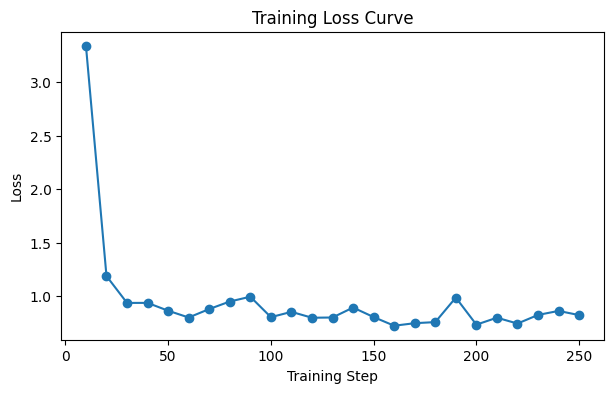

In [20]:
logs = trainer.state.log_history
loss_rows = [{"step": x["step"], "loss": x["loss"]} for x in logs if "loss" in x]

loss_df = pd.DataFrame(loss_rows)
print(loss_df.head())

plt.figure(figsize=(7, 4))
plt.plot(loss_df["step"], loss_df["loss"], marker="o")
plt.title("Training Loss Curve")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.show()

## 21. Test Fine-Tuned Model

In [21]:
FastLanguageModel.for_inference(model)

fine_tuned_response = generate_answer(base_prompt)
print(fine_tuned_response)

Both `max_new_tokens` (=160) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


You are a cybersecurity URL analysis assistant.

Analyze the following URL and decide whether it is safe/benign or phishing/malicious.
Return the answer using this exact format:

Classification:
Risk level:
Reason:

URL: http://login-paypal-security-check.com/verify/account
Classification: phishing/malicious
Risk level: high
Reason: The URL pattern is associated with phishing or malicious behavior in the dataset.


## 22. Side-by-Side Qualitative Comparison

Use this table in the report.

In [22]:
comparison_df = pd.DataFrame([
    {
        "URL": example_url,
        "Base model response": base_response,
        "Fine-tuned model response": fine_tuned_response
    }
])

comparison_df

,URL,Base model response,Fine-tuned model response
0,http://login-paypal-security-check.com/verify/...,You are a cybersecurity URL analysis assistant...,You are a cybersecurity URL analysis assistant...


## 23. Test More URLs

In [23]:
test_urls = [
    "https://www.google.com/search?q=cloud+computing",
    "http://paypal-login-verification-security.com/update",
    "https://queensu.ca/",
    "http://free-gift-card-login-confirm.ru/account"
]

for url in test_urls:
    print("=" * 80)
    print("URL:", url)
    print(generate_answer(build_prompt(url), max_new_tokens=140))

Both `max_new_tokens` (=140) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


URL: https://www.google.com/search?q=cloud+computing


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=140) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


You are a cybersecurity URL analysis assistant.

Analyze the following URL and decide whether it is safe/benign or phishing/malicious.
Return the answer using this exact format:

Classification:
Risk level:
Reason:

URL: https://www.google.com/search?q=cloud+computing
Classification: safe/benign
Risk level: low
Reason: The URL appears consistent with benign web traffic patterns in the dataset.
URL: http://paypal-login-verification-security.com/update


Both `max_new_tokens` (=140) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


You are a cybersecurity URL analysis assistant.

Analyze the following URL and decide whether it is safe/benign or phishing/malicious.
Return the answer using this exact format:

Classification:
Risk level:
Reason:

URL: http://paypal-login-verification-security.com/update
Classification: phishing/malicious
Risk level: high
Reason: The URL pattern is associated with phishing or malicious behavior in the dataset.
URL: https://queensu.ca/


Both `max_new_tokens` (=140) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


You are a cybersecurity URL analysis assistant.

Analyze the following URL and decide whether it is safe/benign or phishing/malicious.
Return the answer using this exact format:

Classification:
Risk level:
Reason:

URL: https://queensu.ca/
Classification: safe/benign
Risk level: low
Reason: The URL appears consistent with benign web traffic patterns in the dataset.
URL: http://free-gift-card-login-confirm.ru/account
You are a cybersecurity URL analysis assistant.

Analyze the following URL and decide whether it is safe/benign or phishing/malicious.
Return the answer using this exact format:

Classification:
Risk level:
Reason:

URL: http://free-gift-card-login-confirm.ru/account
Classification: phishing/malicious
Risk level: high
Reason: The URL pattern is associated with phishing or malicious behavior in the dataset.


## 24. Save Fine-Tuned Adapter

In [24]:
adapter_dir = "url-cybersecurity-lora-adapter"
model.save_pretrained(adapter_dir)
tokenizer.save_pretrained(adapter_dir)

print("Saved adapter to:", adapter_dir)

Unsloth: Restored added_tokens_decoder metadata in url-cybersecurity-lora-adapter/tokenizer_config.json.


Saved adapter to: url-cybersecurity-lora-adapter


## 25. Save Merged Model

If this step is slow or fails because of disk space, skip it and keep the LoRA adapter.

In [25]:
merged_dir = "url-cybersecurity-merged-model"

try:
    model.save_pretrained_merged(merged_dir, tokenizer, save_method="merged_16bit")
    print("Saved merged model to:", merged_dir)
except Exception as e:
    print("Merged model saving failed. This is acceptable if using the LoRA adapter only.")
    print("Error:", repr(e))

config.json:   0%|          | 0.00/894 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in url-cybersecurity-merged-model/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [00:31<00:00, 31.12s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:22<00:00, 22.93s/it]


Unsloth: Merge process complete. Saved to `/content/url-cybersecurity-merged-model`
Saved merged model to: url-cybersecurity-merged-model


## 26. Compress Outputs

In [26]:
!zip -r url-cybersecurity-lora-adapter.zip url-cybersecurity-lora-adapter

import os
if os.path.exists("url-cybersecurity-merged-model"):
    !zip -r url-cybersecurity-merged-model.zip url-cybersecurity-merged-model

  adding: url-cybersecurity-lora-adapter/ (stored 0%)
  adding: url-cybersecurity-lora-adapter/adapter_config.json (deflated 59%)
  adding: url-cybersecurity-lora-adapter/chat_template.jinja (deflated 71%)
  adding: url-cybersecurity-lora-adapter/README.md (deflated 65%)
  adding: url-cybersecurity-lora-adapter/tokenizer_config.json (deflated 96%)
  adding: url-cybersecurity-lora-adapter/tokenizer.json (deflated 85%)
  adding: url-cybersecurity-lora-adapter/adapter_model.safetensors (deflated 8%)
  adding: url-cybersecurity-merged-model/ (stored 0%)
  adding: url-cybersecurity-merged-model/chat_template.jinja (deflated 71%)
  adding: url-cybersecurity-merged-model/model.safetensors (deflated 21%)
  adding: url-cybersecurity-merged-model/config.json (deflated 57%)
  adding: url-cybersecurity-merged-model/tokenizer_config.json (deflated 94%)
  adding: url-cybersecurity-merged-model/.cache/ (stored 0%)
  adding: url-cybersecurity-merged-model/.cache/huggingface/ (stored 0%)
  adding: url-

In [27]:
gguf_dir = "url-cybersecurity-gguf"
model.save_pretrained_gguf(
    gguf_dir,
    tokenizer,
    quantization_method="q4_k_m"
)
print("Saved GGUF model to:", gguf_dir)

Unsloth: Merging model weights to 16-bit format...


Unsloth: Restored added_tokens_decoder metadata in url-cybersecurity-gguf/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [00:15<00:00, 15.99s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:36<00:00, 36.32s/it]


Unsloth: Merge process complete. Saved to `/content/url-cybersecurity-gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: Cloning llama.cpp repository...
Unsloth: Building llama.cpp - please wait 1 to 3 minutes
Unsloth: Successfully installed llama.cpp!
Unsloth: Preparing converter script...


Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['url-cybersecurity-gguf_gguf/Llama-3.2-1B-Instruct.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['url-cybersecurity-gguf_gguf/Llama-3.2-1B-Instruct.Q4_K_M.gguf']
Unsloth: example usage for text only LLMs: /root/.unsloth/llama.cpp/llama-cli --model url-cybersecurity-gguf_gguf/Llama-3.2-1B-Instruct.Q4_K_M.gguf -p "why is the sky blue?"
Unsloth: Saved Ollama Modelfile to url-cybersecurity-gguf_gguf/Modelfile
Unsloth: convert model to ollama format by running - ollama create model_name -f url-cybersecurity-gguf_gguf/Modelfile
Saved GGUF model to: url-cybersecurity-gguf


In [28]:
!zip -r url-cybersecurity-gguf.zip url-cybersecurity-gguf

  adding: url-cybersecurity-gguf/ (stored 0%)
  adding: url-cybersecurity-gguf/chat_template.jinja (deflated 71%)
  adding: url-cybersecurity-gguf/model.safetensors (deflated 21%)
  adding: url-cybersecurity-gguf/config.json (deflated 57%)
  adding: url-cybersecurity-gguf/tokenizer_config.json (deflated 94%)
  adding: url-cybersecurity-gguf/.cache/ (stored 0%)
  adding: url-cybersecurity-gguf/.cache/huggingface/ (stored 0%)
  adding: url-cybersecurity-gguf/.cache/huggingface/.gitignore (stored 0%)
  adding: url-cybersecurity-gguf/.cache/huggingface/CACHEDIR.TAG (deflated 24%)
  adding: url-cybersecurity-gguf/.cache/huggingface/download/ (stored 0%)
  adding: url-cybersecurity-gguf/.cache/huggingface/download/model.safetensors.metadata (deflated 30%)
  adding: url-cybersecurity-gguf/tokenizer.json (deflated 85%)


In [30]:
!ls -lh
!find url-cybersecurity-gguf -name "*.gguf"
!ls -lh url-cybersecurity-gguf.zip

total 3.7G
drwxr-xr-x 4 root root 4.0K Apr 29 15:12 huggingface_tokenizers_cache
drwxr-xr-x 4 root root 4.0K Apr 29 15:16 outputs
drwxr-xr-x 1 root root 4.0K Apr 16 13:33 sample_data
drwxr-xr-x 4 root root 4.0K Apr 29 15:12 unsloth_compiled_cache
drwxr-xr-x 3 root root 4.0K Apr 29 15:23 url-cybersecurity-gguf
drwxr-xr-x 2 root root 4.0K Apr 29 15:40 url-cybersecurity-gguf_gguf
-rw-r--r-- 1 root root 1.9G Apr 29 15:46 url-cybersecurity-gguf.zip
drwxr-xr-x 2 root root 4.0K Apr 29 15:16 url-cybersecurity-lora-adapter
-rw-r--r-- 1 root root  43M Apr 29 15:17 url-cybersecurity-lora-adapter.zip
drwxr-xr-x 3 root root 4.0K Apr 29 15:17 url-cybersecurity-merged-model
-rw-r--r-- 1 root root 1.9G Apr 29 15:22 url-cybersecurity-merged-model.zip
-rw-r--r-- 1 root root 1.9G Apr 29 15:46 url-cybersecurity-gguf.zip


In [32]:
!find url-cybersecurity-gguf -name "*.gguf"

In [33]:
!zip -r real-gguf-only.zip url-cybersecurity-gguf_gguf
!ls -lh real-gguf-only.zip

  adding: url-cybersecurity-gguf_gguf/ (stored 0%)
  adding: url-cybersecurity-gguf_gguf/Llama-3.2-1B-Instruct.Q4_K_M.gguf (deflated 2%)
  adding: url-cybersecurity-gguf_gguf/Modelfile (deflated 65%)
-rw-r--r-- 1 root root 754M Apr 29 16:11 real-gguf-only.zip


## 27. Hyperparameter Summary

| Item | Value |
|---|---|
| Base model | Llama-3.2-1B-Instruct 4-bit, fallback Qwen2.5-1.5B-Instruct 4-bit |
| Fine-tuning method | QLoRA / PEFT |
| LoRA rank | 16 |
| LoRA alpha | 16 |
| Max sequence length | 512 |
| Batch size | 2 |
| Gradient accumulation | 4 |
| Learning rate | 2e-4 |
| Max training steps | 250 |
| Optimizer | adamw_8bit |
| Dataset | semihGuner2002/PhishingURLsDataset |
| Task | URL phishing/malicious vs safe/benign chatbot assistant |